# Time Series Analysis Using Arima And Sarima
## Grammatikou Petros 03366 
## Doumos Ioannis 03238

To address the problem of forecasting once again (this time not in the lab but using the most of what we learned there) we decided to do it on a very real βθτ also very hot and challenging topic. The Bitcoin! We know that this will be hard problem to solve and for the simple reason if it wasn't many people would have been rich from that. But why is it so hard??? Let's find out!

- the data set is sent to you in the same folder with this notebook.
- we chose to implement the code in python because it offers bigger range of functions for future expansions that we want to give to the project


In [1]:
# functions and imports:
from sklearn.metrics import mean_squared_error
from IPython.display import display
import numpy as np
import pandas as pd
pd.set_option('display.max_rows', 15)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
import matplotlib.pyplot as plt
from datetime import datetime
from datetime import timedelta
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from time import time
import seaborn as sns
sns.set(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')
RANDOM_SEED = np.random.seed(0)


# code from statistics class
def check_stationarity(ts):
    dftest = adfuller(ts)
    adf = dftest[0]
    pvalue = dftest[1]
    critical_value = dftest[4]['5%']
    if (pvalue < 0.05) and (adf < critical_value):
        print('The series is stationary')
    else:
        print('The series is NOT stationary')

        

# arima made with a function
def ARIMA_model(y, test_data, order):
    """
    Fits an ARIMA model to the training data and evaluates it on the test data.
    
    Parameters:
    - y: Training data (Pandas Series or DataFrame with a 'close' column)
    - test_data: Test data (Pandas DataFrame with a 'close' column)
    - order: Tuple representing the (p, d, q) order of the ARIMA model
    
    Returns:
    - arima_rmse: RMSE of the ARIMA model on the test data
    - y_pred_df: DataFrame containing the confidence interval and predictions
    """
    # Fit the ARIMA model
    arima = ARIMA(y['close'], order=order)
    arima_fitted = arima.fit()

    # Forecast for the test period
    y_pred = arima_fitted.get_forecast(len(test_data.index))
    y_pred_df = y_pred.conf_int(alpha=0.05)
    y_pred_df["Predictions"] = arima_fitted.predict(
        start=y_pred_df.index[0], end=y_pred_df.index[-1]
    )
    y_pred_df.index = test_data.index
    y_pred_out = y_pred_df["Predictions"]

    # Plot the results
    plt.figure(figsize=(12, 6))
    plt.plot(y_pred_out, color='green', label='ARIMA Predictions')
    plt.plot(y, color="black", label="Train Data")
    plt.plot(test_data, color="red", label="Test Data")
    plt.ylabel('BTC Price')
    plt.xlabel('Date')
    plt.xticks(rotation=45)
    plt.title(f"Train/Test split with ARIMA Predictions (Order: {order})")
    plt.legend()
    plt.grid()
    plt.show()

    # Calculate RMSE
    arima_rmse = np.sqrt(mean_squared_error(test_data["close"].values, y_pred_out))
    print(f"ARIMA RMSE (Order: {order}): {arima_rmse}")
    
    return arima_rmse, y_pred_df

# Sarima made with a function
def SARIMA_model(y, test_data, order, seasonal_order):
    """
    Fits a SARIMA model to the training data and evaluates it on the test data.
    
    Parameters:
    - y: Training data (Pandas Series or DataFrame with a 'close' column)
    - test_data: Test data (Pandas DataFrame with a 'close' column)
    - order: Tuple representing the (p, d, q) order of the SARIMA model
    - seasonal_order: Tuple representing the seasonal order (P, D, Q, m)
    
    Returns:
    - sarima_rmse: RMSE of the SARIMA model on the test data
    - y_pred_df: DataFrame containing the confidence interval and predictions
    """
    # Fit the SARIMA model
    sarima = SARIMAX(
        y['close'],
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    sarima_fitted = sarima.fit(disp=False)

    # Forecast for the test period
    y_pred = sarima_fitted.get_forecast(steps=len(test_data.index))
    y_pred_df = y_pred.conf_int(alpha=0.05)
    y_pred_df["Predictions"] = y_pred.predicted_mean
    y_pred_df.index = test_data.index
    y_pred_out = y_pred_df["Predictions"]

    # Plot the results
    plt.figure(figsize=(14, 6))
    plt.plot(y_pred_out, color='green', label='SARIMA Predictions')
    plt.plot(y, color="black", label="Training Data")
    plt.plot(test_data, color="red", label="Test Data")
    plt.ylabel('BTC Price')
    plt.xlabel('Date')
    plt.xticks(rotation=45)
    plt.title(f"Train/Test Split with SARIMA Predictions (Order: {order}, Seasonal Order: {seasonal_order})")
    plt.legend()
    plt.grid()
    plt.show()

    # Calculate RMSE
    sarima_rmse = np.sqrt(mean_squared_error(test_data['close'].values, y_pred_out))
    print(f"SARIMA RMSE (Order: {order}, Seasonal Order: {seasonal_order}): {sarima_rmse}")
    
    return sarima_rmse, y_pred_df

# Brute force testing All the posiblemodels to find the best
def find_best_arima_model(train_data, test_data):
    """
    Finds the best ARIMA model by testing combinations of (p, d, q) orders.

    Parameters:
    - train_data: Training data (Pandas Series or DataFrame with a 'close' column)
    - test_data: Test data (Pandas DataFrame with a 'close' column)

    Returns:
    - best_order: The (p, d, q) order that achieved the lowest RMSE
    """
    p_range = range(0, 4)
    d_range = range(0, 3)
    q_range = range(0, 4)

    best_rmse = float("inf")
    best_order = None
    best_model = None

    # Iterate over all combinations of p, d, q
    for p in p_range:
        for d in d_range:
            for q in q_range:
                # Fit ARIMA model
                arima = ARIMA(train_data['close'], order=(p, d, q))
                arima_fitted = arima.fit()

                # Forecast for the test period
                y_pred = arima_fitted.forecast(steps=len(test_data.index))

                # Calculate RMSE
                rmse = np.sqrt(mean_squared_error(test_data['close'], y_pred))

                # Update the best model if RMSE is lower
                if rmse < best_rmse:
                    best_rmse = rmse
                    best_order = (p, d, q)
                    best_model = arima_fitted


    print(f"Best ARIMA Order: {best_order} with RMSE: {best_rmse}")
    return best_order


def find_best_sarima_model(train_data, test_data, s):
    """
    Finds the best SARIMA model by testing combinations of (p, d, q) and seasonal (P, D, Q, s) orders.

    Parameters:
    - train_data: Training data (Pandas Series or DataFrame with a 'close' column)
    - test_data: Test data (Pandas DataFrame with a 'close' column)
    - s: Seasonal period (e.g., 7 for weekly seasonality)

    Returns:
    - best_order: The (p, d, q) order that achieved the lowest RMSE
    - best_seasonal_order: The (P, D, Q, s) seasonal order that achieved the lowest RMSE

    """
    p_range = range(0, 4)    # AR terms
    d_range = range(0, 3)    # Differencing terms
    q_range = range(0, 4)    # MA terms
    P_range = range(0, 3)    # Seasonal AR terms
    D_range = range(0, 2)    # Seasonal differencing terms
    Q_range = range(0, 3)    # Seasonal MA terms
    
    best_rmse = float("inf")
    best_order = None
    best_seasonal_order = None
    best_model = None

    # Iterate over all combinations of parameters
    for p in p_range:
        for d in d_range:
            for q in q_range:
                for P in P_range:
                    for D in D_range:
                        for Q in Q_range:
                            # Fit SARIMA model
                            sarima = SARIMAX(
                                train_data['close'],
                                order=(p, d, q),
                                seasonal_order=(P, D, Q, s),
                                enforce_stationarity=False,
                                enforce_invertibility=False
                            )
                            sarima_fitted = sarima.fit(disp=False)

                            # Forecast for the test period
                            y_pred = sarima_fitted.forecast(steps=len(test_data.index))

                            # Calculate RMSE
                            rmse = np.sqrt(mean_squared_error(test_data['close'], y_pred))

                            # Update best model if RMSE is lower
                            if rmse < best_rmse:
                                best_rmse = rmse
                                best_order = (p, d, q)
                                best_seasonal_order = (P, D, Q, s)
                                best_model = sarima_fitted
                            

    print(f"Best SARIMA Order: {best_order}, Seasonal Order: {best_seasonal_order} with RMSE: {best_rmse}")
    return best_order, best_seasonal_order

In [2]:
# Load the dataset
file_path = 'BTC-2021_01_01_2022_03_01_min_basis.csv'
df = pd.read_csv(file_path)

# get rid of useless information
df.drop(columns=["symbol"], inplace=True)

df.head()


,unix,date,open,high,low,close,Volume BTC,Volume USD
0,1646106180,2022-03-01 03:43:00,43046.58,43046.58,43046.58,43046.58,0.000000,0.000000
1,1646106060,2022-03-01 03:41:00,43018.23,43046.59,43018.23,43046.58,0.142977,6154.673021
2,1646106000,2022-03-01 03:40:00,43022.24,43022.24,43016.03,43016.03,0.009230,397.037957
3,1646105940,2022-03-01 03:39:00,43035.16,43035.16,42999.44,42999.44,0.820950,35300.390268
4,1646105880,2022-03-01 03:38:00,43077.82,43077.82,43049.46,43049.46,0.022210,956.143143


               close  Volume BTC  Volume USD
close       1.000000    -0.10964   -0.021363
Volume BTC -0.109640     1.00000    0.973580
Volume USD -0.021363     0.97358    1.000000


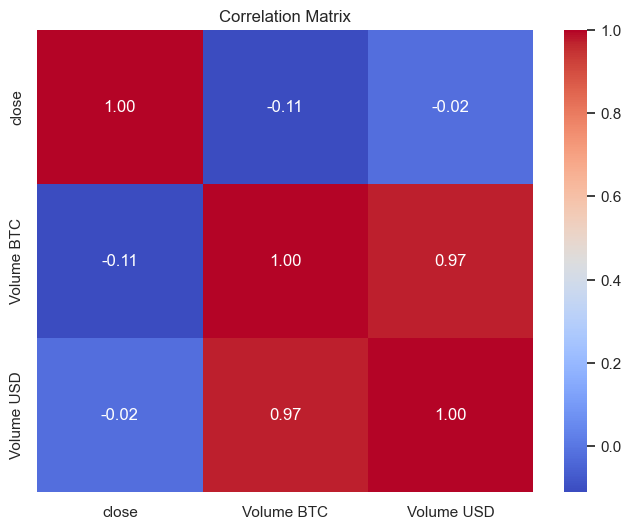

In [3]:
# Check the importance of Volume values
correlation_matrix = df[['close', 'Volume BTC', 'Volume USD']].corr()
print(correlation_matrix)

# Visualize correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()


### The Volume columns seem to have minimal correlation with the bitcoin value.

In [4]:
#Discard them
df.drop(columns=["Volume BTC"], inplace=True)
df.drop(columns=["Volume USD"], inplace=True)

df.head()


,unix,date,open,high,low,close
0,1646106180,2022-03-01 03:43:00,43046.58,43046.58,43046.58,43046.58
1,1646106060,2022-03-01 03:41:00,43018.23,43046.59,43018.23,43046.58
2,1646106000,2022-03-01 03:40:00,43022.24,43022.24,43016.03,43016.03
3,1646105940,2022-03-01 03:39:00,43035.16,43035.16,42999.44,42999.44
4,1646105880,2022-03-01 03:38:00,43077.82,43077.82,43049.46,43049.46


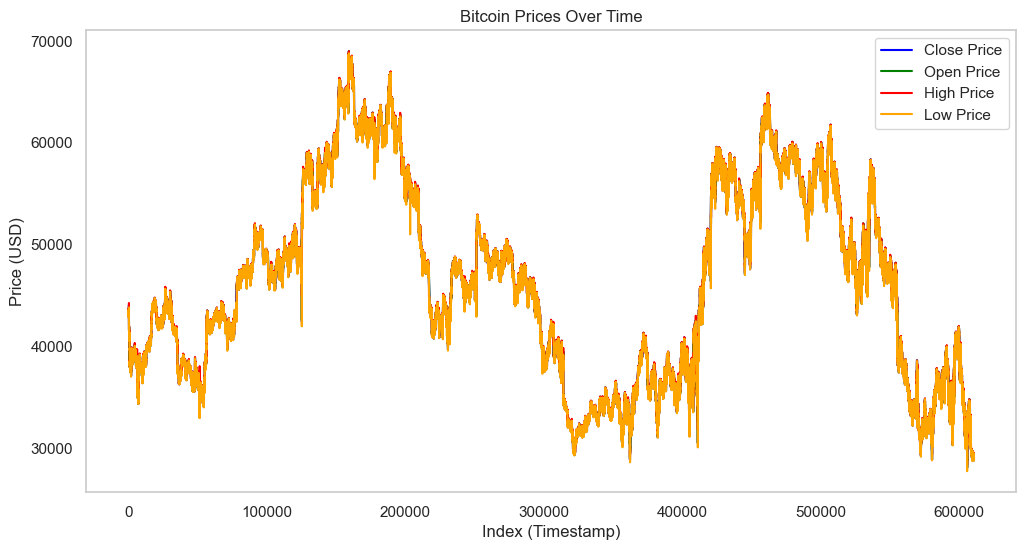

In [5]:
# Observe the data
plt.figure(figsize=(12, 6))
plt.plot(df['close'], label='Close Price', color='blue')
plt.plot(df['open'], label='Open Price', color='green')
plt.plot(df['high'], label='High Price', color='red')
plt.plot(df['low'], label='Low Price', color='orange')

# Add titles and labels
plt.title('Bitcoin Prices Over Time')
plt.xlabel('Index (Timestamp)')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid()
plt.show()

### All the values are so similar that if we manage to predict one we will know the others! 
So we are gonna get rid of the most pf them and only use the close value!

In [6]:
df.drop(columns=["open"], inplace=True)
df.drop(columns=["high"], inplace=True)
df.drop(columns=["low"], inplace=True)

# close is also the most comonly used in ARIMA models
df.head()


,unix,date,close
0,1646106180,2022-03-01 03:43:00,43046.58
1,1646106060,2022-03-01 03:41:00,43046.58
2,1646106000,2022-03-01 03:40:00,43016.03
3,1646105940,2022-03-01 03:39:00,42999.44
4,1646105880,2022-03-01 03:38:00,43049.46


### From the plot we know that the series in not stationary, but lets test it in code too! Knowing that a time series is not stationary makes it harder to predict.

In [61]:
# NO NEED TO RUN AGAIN, TAKES TIME

# out: the series is NOT stationary

# NO WONDER

# check_stationarity(df["close"])


The series is NOT stationary


### We are gonna carry out analysis for minute data but also make a daily analysis too!
### For the daily strategy lets say we want to cash out in a monent within the day that we observe the value is larger than the man predicted value. We need to calculate all the days mean and make predictions based on that!

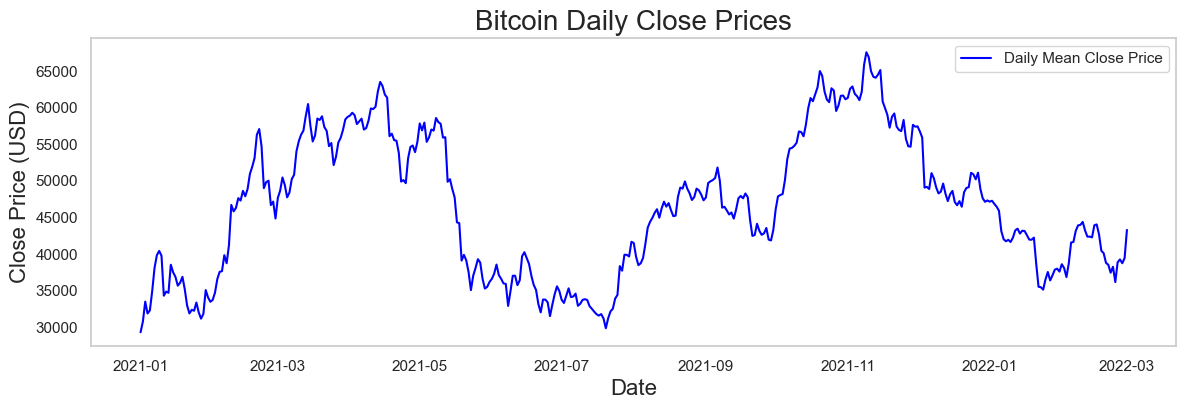

In [54]:
# normalize the 'date' column and remove hours and minutes
date_only = pd.read_csv(file_path)
date_only['date'] = pd.to_datetime(date_only['unix'], unit='s').dt.normalize()

# Aggregate data to daily mean
daily_data = date_only.groupby('date')['close'].mean().to_frame(name='close')

# Infer the frequency of the data
daily_data = daily_data.asfreq(pd.infer_freq(daily_data.index))

# Plot daily mean close price
plt.figure(figsize=(14, 4))
plt.plot(daily_data, label="Daily Mean Close Price", color='blue')
plt.title('Bitcoin Daily Close Prices', fontsize=20)
plt.ylabel('Close Price (USD)', fontsize=16)
plt.xlabel('Date', fontsize=16)
plt.legend()
plt.grid()
#plt.show()


### A seasonal decomposition would be gread for exploring our data and trying to figure out if there are paterns that we can model to get good predictions. 
Seasonal decomposition is a statistical technique used to break down a time series into its constituent components. The components are trend, seasonality, and residual and they model:
- Trend: The long-term changes or patterns that are observed over time and the general direction in which the data is moving
- Seasonality: The repeating short-term patterns or cycles that occur at regular intervals
- Residual: Random noise or unexplained variations

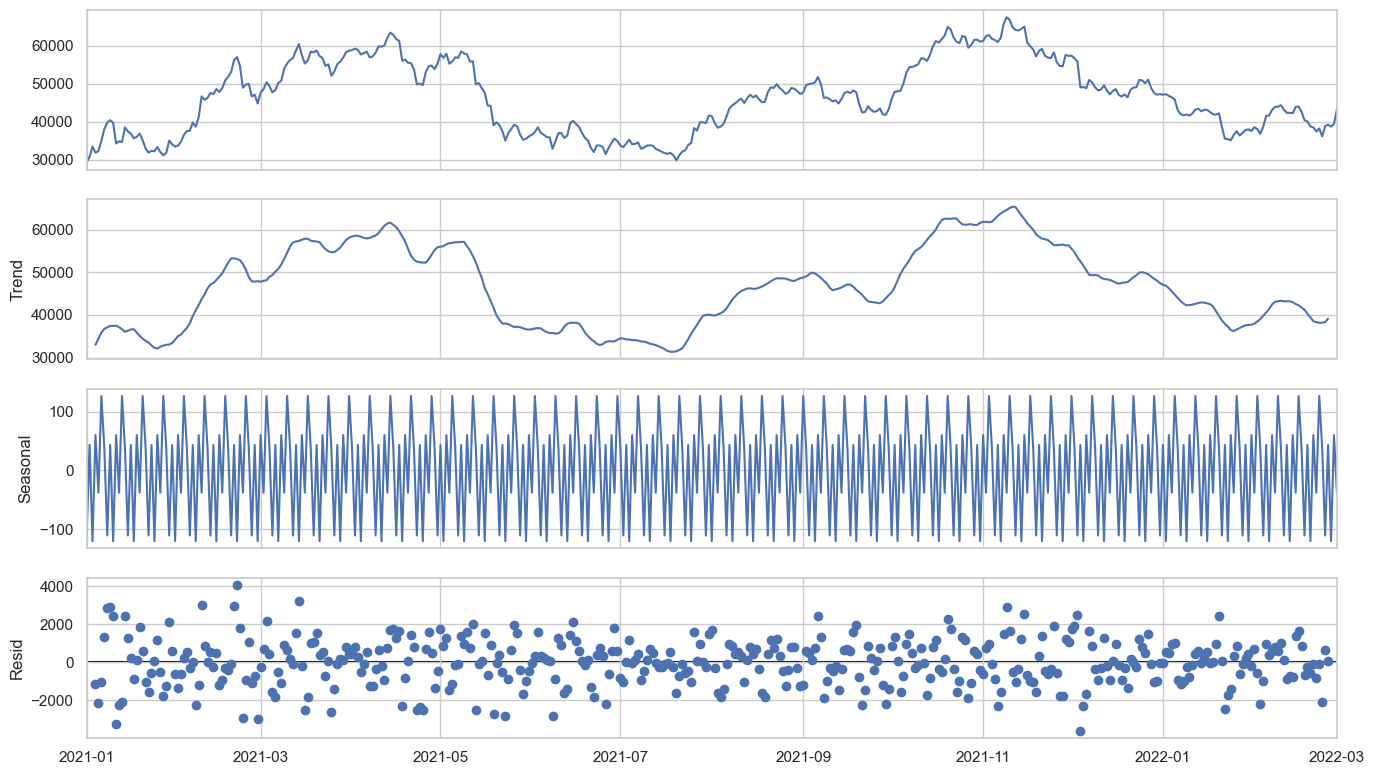

In [42]:
# We perform a seasonal decomposition here 

plt.rc('figure',figsize=(14,8))
plt.rc('font',size=15)
result = seasonal_decompose(daily_data, model='additive')
fig = result.plot()


### A bad omen for the prediction accuracy of our models is shown here! We are not sure if the sesonal component did "catch" an existing patern but most importantly the residual seems to play a very important role in the decomposition. We can see that the dynamic rane of the residuals is more than the 7000 whitch means that the spikes and many of the flactuations that the data show are modeled as noise by big residaulal values! Unfortunately, noise is something that we can not predict...

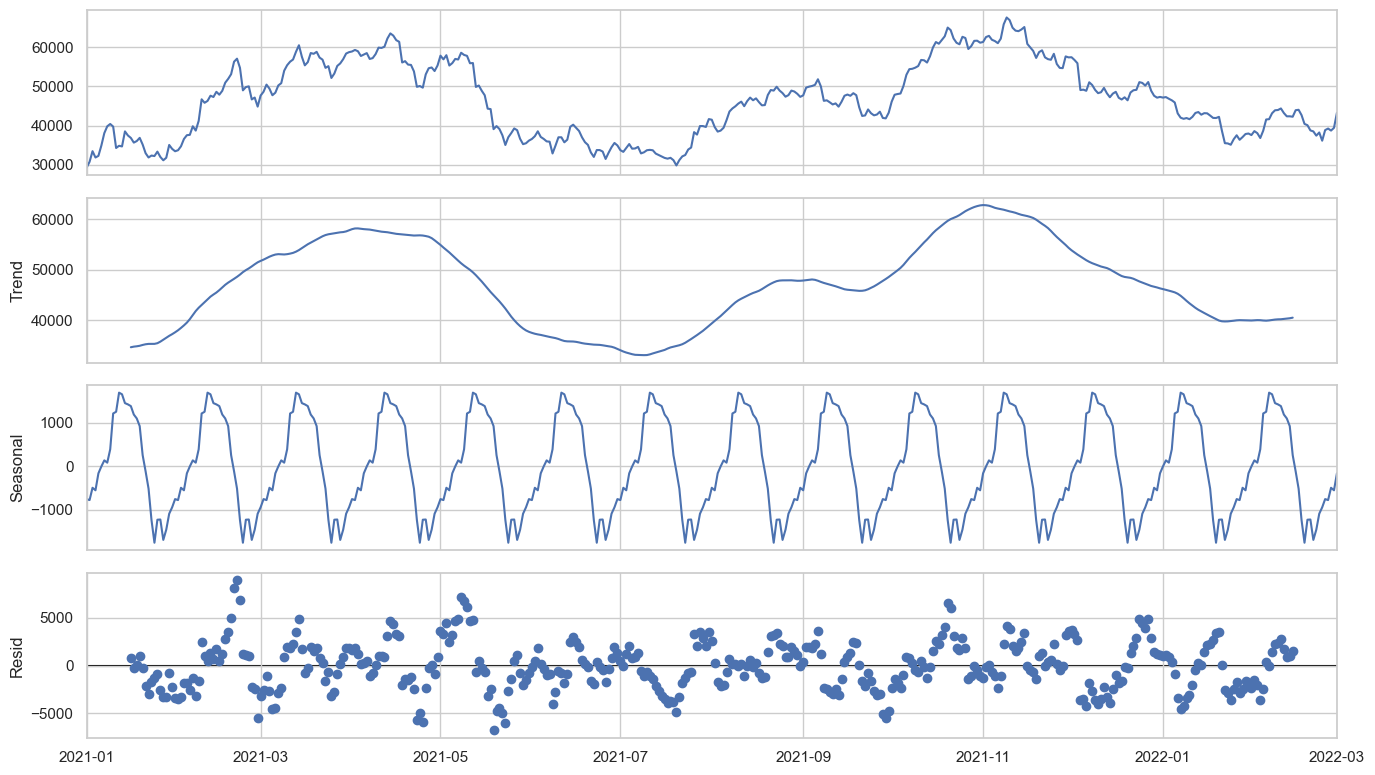

In [51]:
# Perform seasonal decomposition
result = seasonal_decompose(daily_data, model='additive', period=30) # lets see the monthly too
fig = result.plot()
plt.show()
# of course ti will have even worse results

### We already know that the daily data is hard to predict, lets make the same analysis on the original minutely data too.

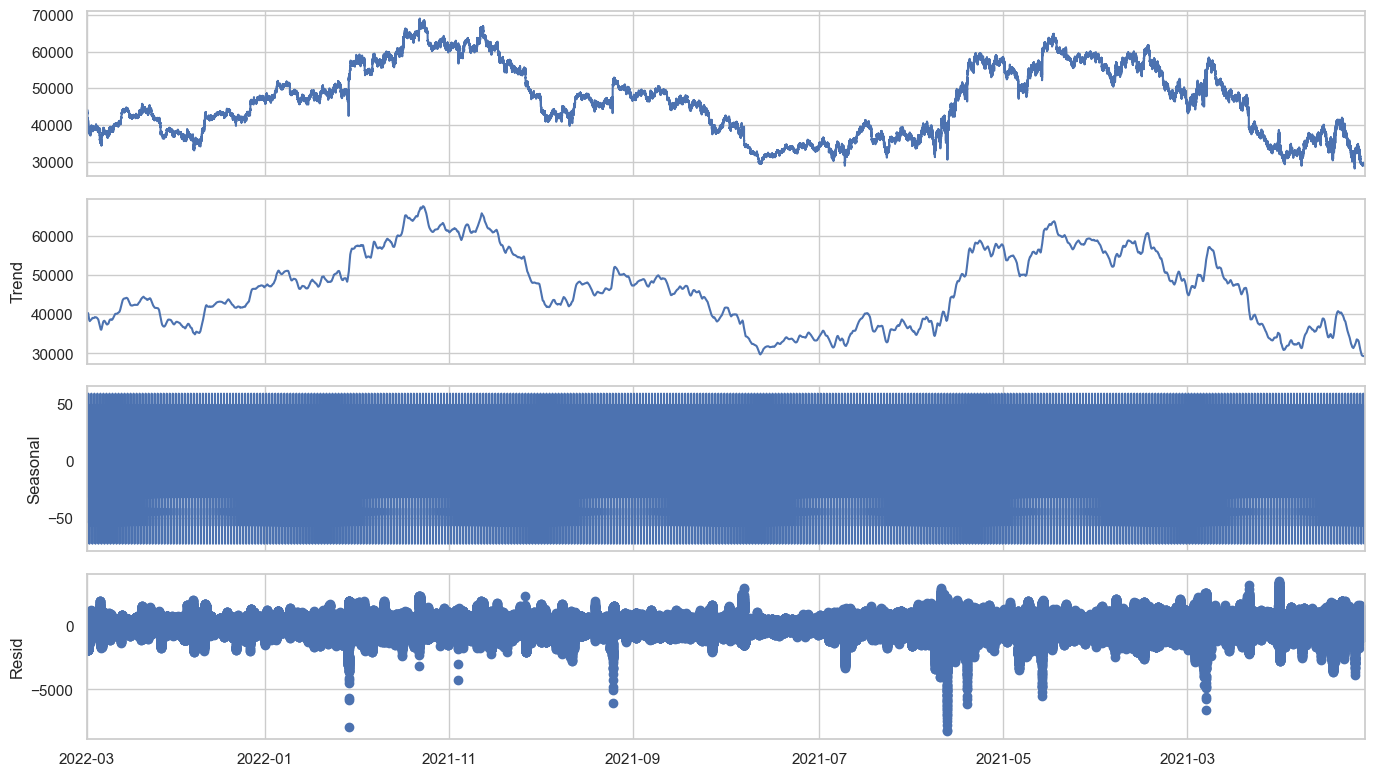

In [52]:
# Perform seasonal decomposition
result = seasonal_decompose(df, model='additive', period=1440)  # daily
fig = result.plot()
plt.show()

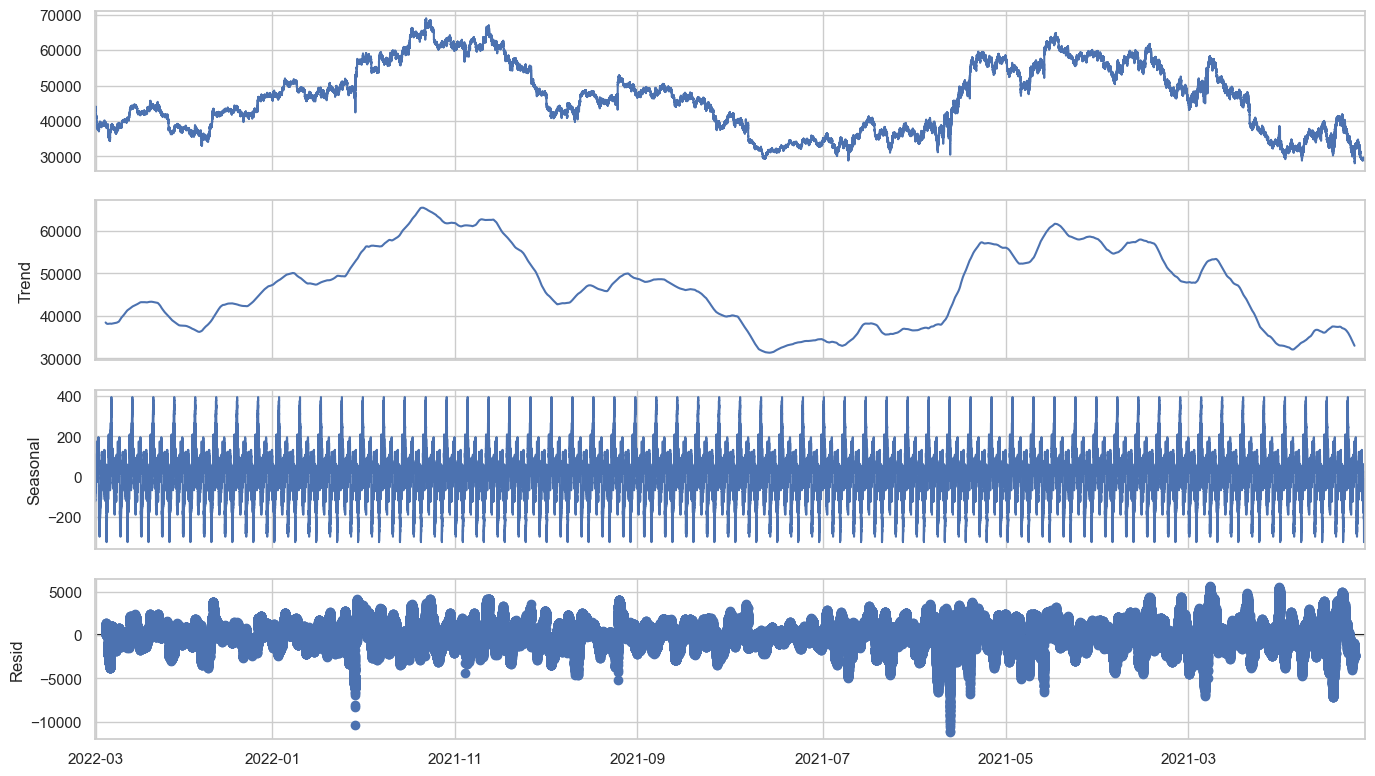

In [53]:
# Perform seasonal decomposition
result = seasonal_decompose(df, model='additive', period = 10080)  # weekly
fig = result.plot()
plt.show()

### Even in the daily analysis we obsereve that are big flactuations modeled as noise by the residual...

## Next up we will explore the Correlation and Autocorrelation of the data
### Autocorrelation:
The correlation between two values in a time series. In other words, the time series data correlate with themselves—hence, the name
### Partial Autocorrelation:
Similar to the ACF except that it displays only the correlation between two observations that the shorter lags between those observations do not explain

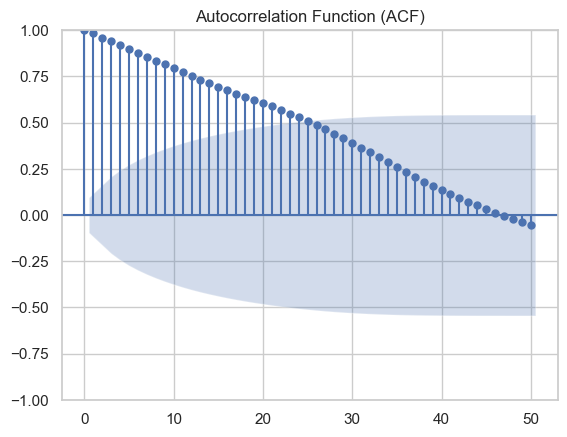

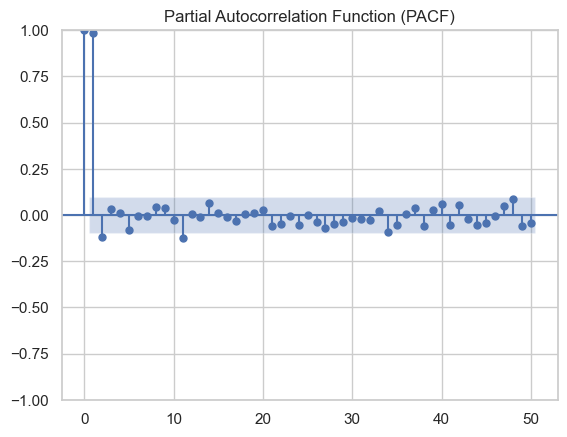

In [11]:
# Plot ACF and PACF for the 'close' column DAILY
plot_acf(daily_data['close'], lags=50)
plt.title('Autocorrelation Function (ACF)')
plt.show()

plot_pacf(daily_data['close'], lags=50)
plt.title('Partial Autocorrelation Function (PACF)')
plt.show()

### Autocorrelation Daily Data
- When trends are present in a time series, shorter lags typically have large positive correlations because observations closer in time tend to have similar values. The correlations taper off slowly as the lags increase. This gives away information about how much our models should "look back in time" to calculate the future values! The decrease in correlation is almost linear so a linear decline in the weights of the lasts days would be reasonable.
### Partial Autocorrelation
- On the graph, the partial autocorrelations for lags 1 and 2 are statistically significant. The subsequent lags are nearly significant. Consequently, this PACF suggests fitting either a second or third-order autoregressive model.

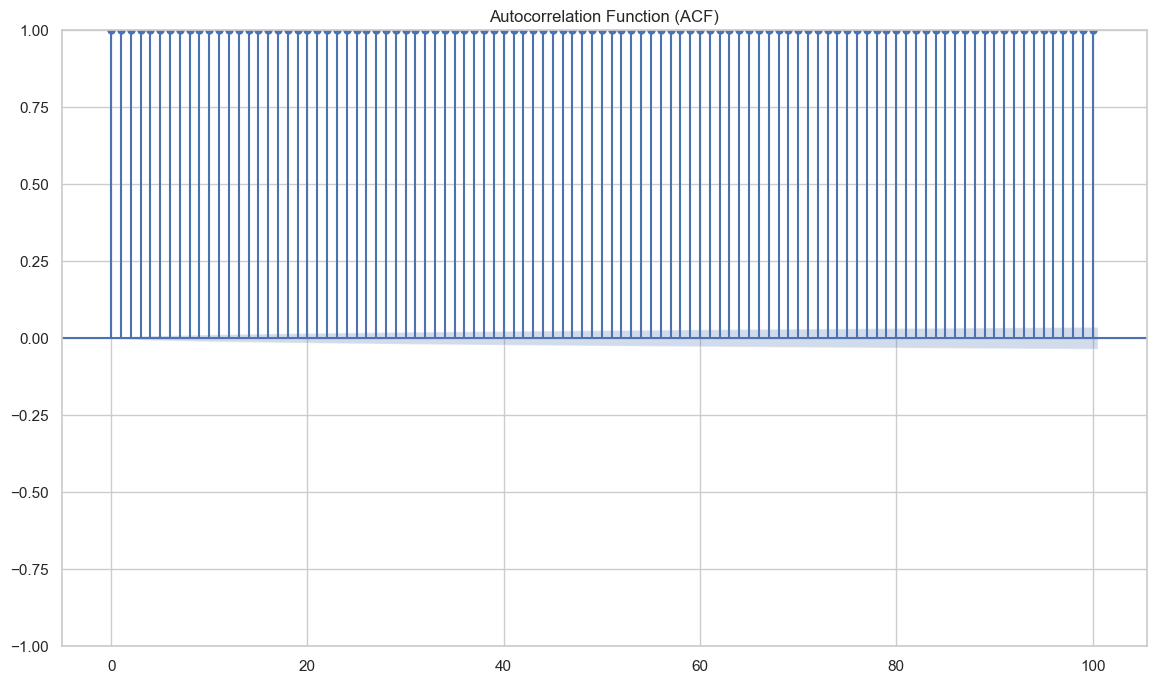

In [55]:
# Lets ACF for the 'close' column EVERY MINUTE (the original data set) (it takes some time)
plot_acf(df['close'], lags=100)
plt.title('Autocorrelation Function (ACF)')
plt.show()


- this graph seems meaningless as it tells us that the past minutes are highly correlated with the value of the current moment 

In [13]:
# actually we dont need unix eihter
df.drop(columns=["unix"], inplace=True)
df.head()

,date,close
0,2022-03-01 03:43:00,43046.58
1,2022-03-01 03:41:00,43046.58
2,2022-03-01 03:40:00,43016.03
3,2022-03-01 03:39:00,42999.44
4,2022-03-01 03:38:00,43049.46


In [14]:
#split the data
train_daily = daily_data[daily_data.index < pd.to_datetime("2022-02-19", format='%Y-%m-%d')]
test_daily = daily_data[daily_data.index >= pd.to_datetime("2022-02-19", format='%Y-%m-%d')]

# minutel data
# Needed convertions first to use the < operator ONLY THE FIRST TIME YOU RUN THAT
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d %H:%M:%S')
df = df.set_index('date')

#split
train_df = df[df.index < pd.to_datetime("2022-02-19", format='%Y-%m-%d')]
test_df = df[df.index >= pd.to_datetime("2022-02-19", format='%Y-%m-%d')]



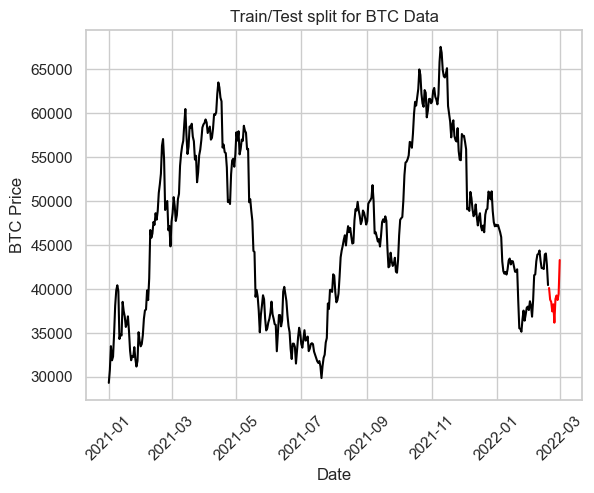

In [15]:
plt.plot(train_daily, color = "black")
plt.plot(test_daily, color = "red")
plt.ylabel('BTC Price')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.title("Train/Test split for BTC Data")
plt.show()


### By utilizing the functions that iteratively run all the models and return the best one we will discover whitch to use. We know that this will take a long time, but once it is done once we wont need to do that again! 

In [16]:
# Lets find the best Model. GO BRUTE FORCE 

# out: Best ARIMA Order: (0, 2, 3) with RMSE: 1839.1763059128546

#order = find_best_arima_model(train_daily, test_daily)

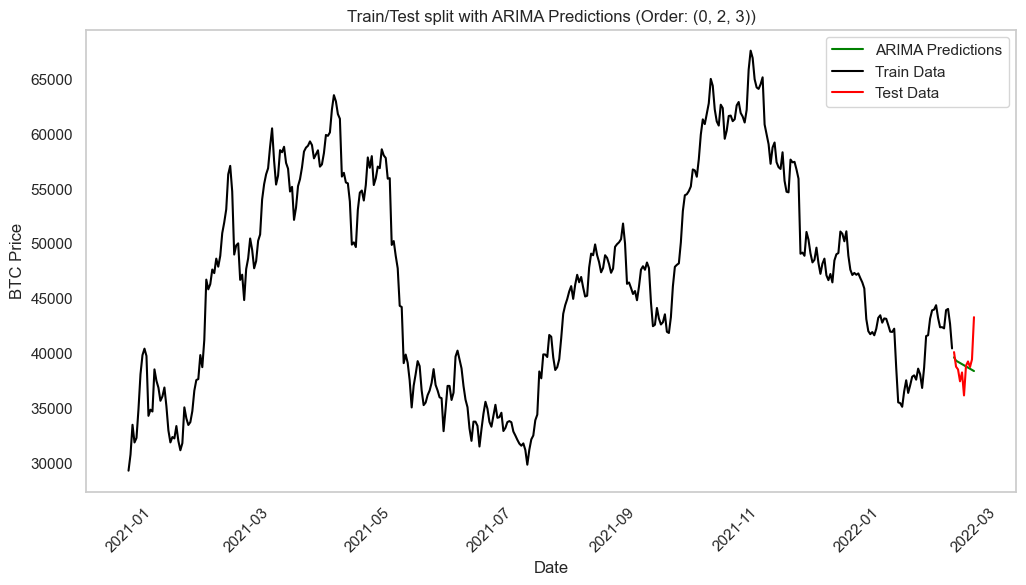

ARIMA RMSE (Order: (0, 2, 3)): 1839.1763059128546


In [17]:
# Call the ARIMA_model function
order = (0, 2, 3)
arima_rmse_daily, arima_predictions_daily = ARIMA_model(train_daily, test_daily, order)



### ARIMA model almost catches the decline but cannot predict the incline later...

In [18]:
# it takes A LOT LOT OF time... DONT RUN 
# output is: Best SARIMA Order: (3, 2, 3) Seasonal Order: (2, 0, 2, 7) with RMSE: {best_rmse}

#best_order, best_seasonal_order = find_best_sarima_model(train_daily, test_daily, s=7)

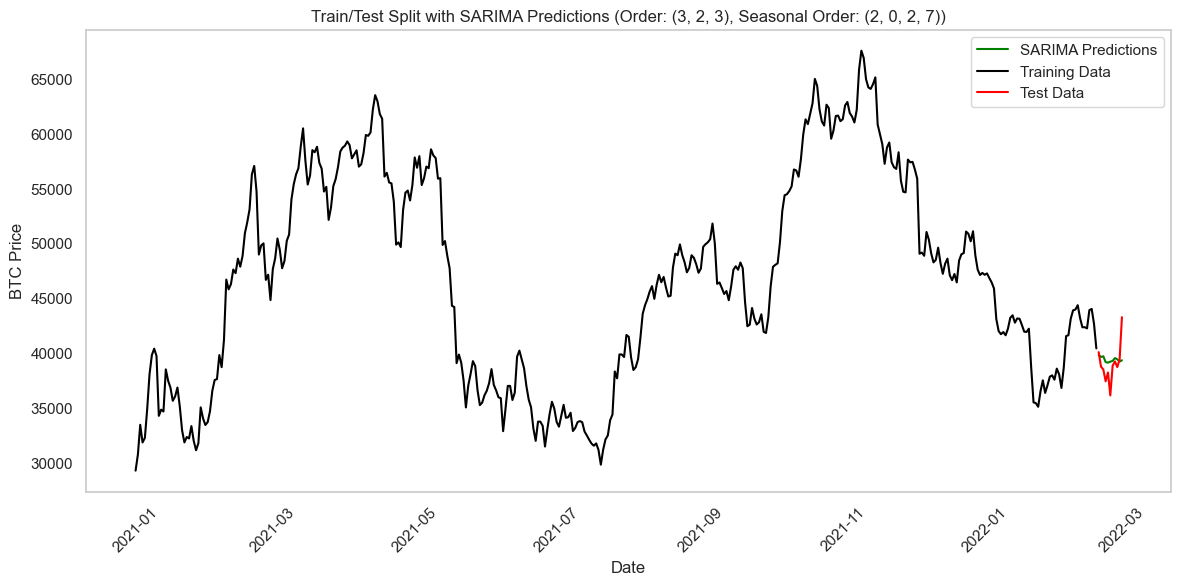

SARIMA RMSE (Order: (3, 2, 3), Seasonal Order: (2, 0, 2, 7)): 1701.1043942911829


In [19]:
# Call the SARIMA_model function
best_order = (3, 2, 3)
best_seasonal_order = (2, 0, 2, 7)
sarima_rmse_daily, sarima_predictions_daily = SARIMA_model(train_daily, test_daily, best_order, best_seasonal_order)



### SARIMA seems slightly better but in general has similar behaviour with the ARIMA model

### Now lets test the models on minute data

In [ ]:
# THIS TAKES A WHOLE DAY TO RUN

# out: Best ARIMA Order: (2, 0, 1) with RMSE: 6931.746804981133

# find best arima model
#order = find_best_arima_model(train_df, test_df)


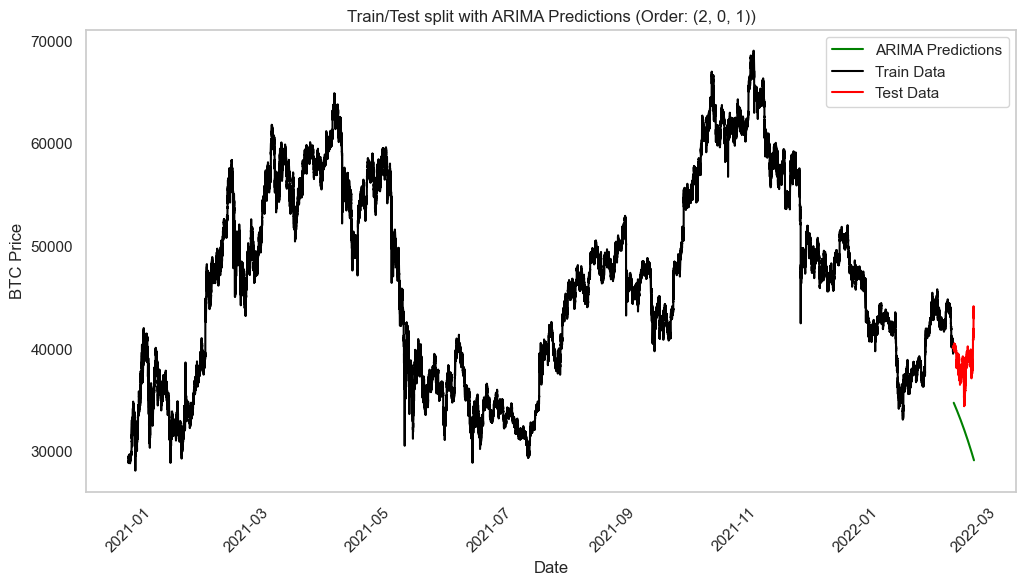

ARIMA RMSE (Order: (2, 0, 1)): 6931.746804981133


In [21]:
# Call the ARIMA_model function
order = (2, 0, 1)
rmse, predictions = ARIMA_model(train_df, test_df, order)


In [56]:
# it takes A LOT LOT OF time... AND IN THE END CMPUTATIONAL POWER IS NOT ENOUGH AS IT RUNS
#  OUT ON MEMORY IF WE RUN LOCALY. ON GOOGLE COLLAB IT JUXT STOPS WITHOUT ANY ERROR MESSAGE...
# So what we gonna do is use the model we found to be best for the daily data.
# It probably is not the best though...

#best_order, best_seasonal_order = find_best_sarima_model(train_df, test_df, s=60)

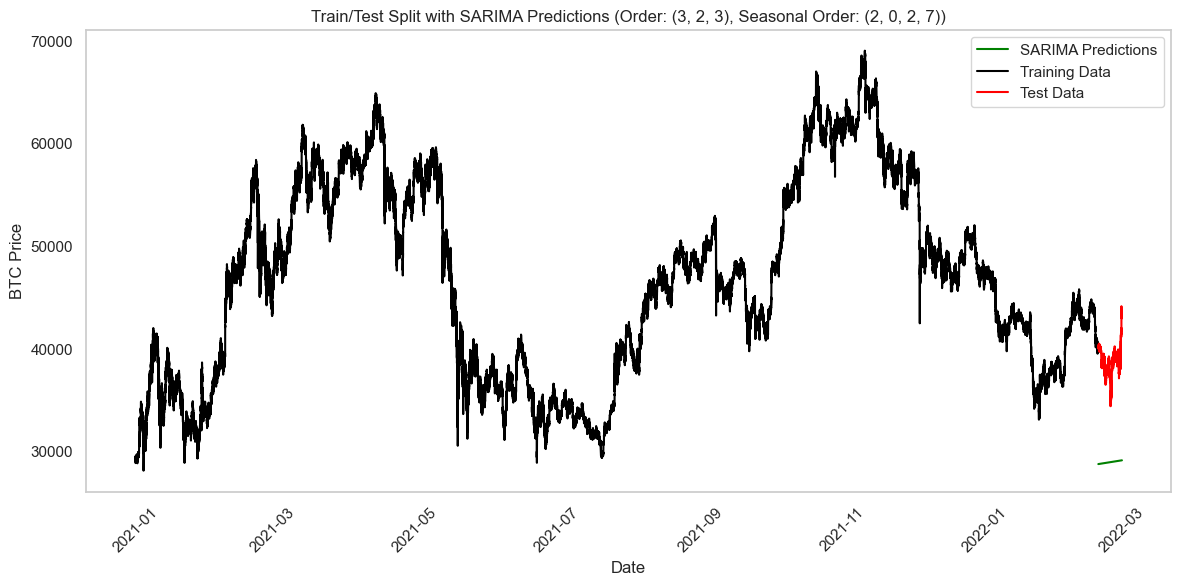

SARIMA RMSE (Order: (3, 2, 3), Seasonal Order: (2, 0, 2, 7)): 9814.003236210394


In [60]:
# Call the SARIMA_model function
best_order = (3, 2, 3)
best_seasonal_order = (2, 0, 2, 7)
sarima_rmse_df, sarima_predictions_dd = SARIMA_model(train_df, test_df, best_order, best_seasonal_order)


### In the minutely data both ARIMA and SARIMA  have terrible performance! Much worse than on daily data... in this case it almost seems like they cant handle the scale and the complexity of the problem and that the prediction is useless!

# Conclusions:
After all in this project we have shown that not every data set is possible to be predicted with a satisfying precision. Bitcoin is one of them! The randomness it appears to have as a time series with two variables (time as x and value as y)  or the latent factors that can determine its value in real time (which are a lot as they apply to the real world, eg: regulatory news and laws, market sentiment, or macroeconomic conditions) and are not portrait in the data set make it extremely difficult to predict precisely! Of course all the techniques we applied would work more effectively on a dataset with clearer patterns and fewer external influences. The reason we chose this data set was to go to the extremes and push these algorithms to their limits , allowing us to not only observe where their predictive power breaks down but also understand why this happens and how to identify such challenges before attempting a forecast. The biggest gain of all this proccess is that in similar problems we now know how to handle and analyse the data to get a better understanding of the data but also what to expect our model to perform after that.

### The Next Step
The Next Step is trying to address the same problem with the most cutting edge technology of our times in the field of data science which is neural networks. Many times neural networks have shown that through the enormus amount of parameters they have can give us surprisingly good results that the classical model could never achieve .An LLM is considered a good choice to address such problems as it is specifically designed to handle sequential data and capture long-range dependencies with their recurrent nature that traditional statistical models might miss. This journey is about to be even more exciting!